L2 error at t=0.1: 2.1413956995093488e-5


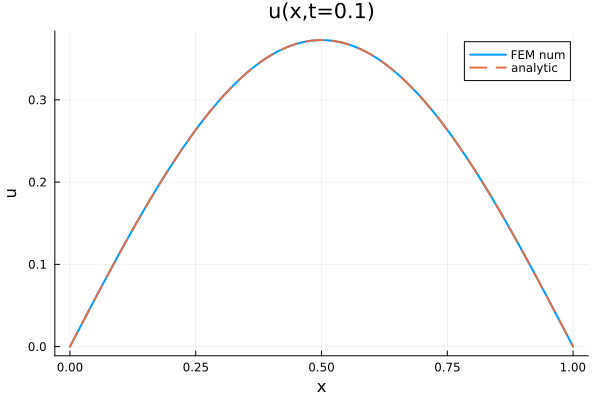

In [1]:
using SparseArrays, LinearAlgebra, Plots

# --------------------
# Parameters & mesh
# --------------------
D = 1.0                     # diffusion coefficient
L = 1.0                     # domain length
Ne = 100                    # number of elements
N = Ne + 1                  # number of nodes
h = L/Ne
nodes = range(0.0, L, length=N)

# time
t0 = 0.0
tfinal = 0.1
dt = 1e-4                   # time step (adjust)
θ = 0.5                     # theta = 0.5 -> Crank-Nicolson

# --------------------
# Assemble M and K
# --------------------
nb = N
I = Int[]
J = Int[]
V = Float64[]

function add_entry!(i,j,val)
    push!(I,i); push!(J,j); push!(V,val)
end

for e in 1:Ne
    n1 = e
    n2 = e+1
    # local matrices
    Me = (h/6.0) * [2.0 1.0; 1.0 2.0]
    Ke = (1.0/h) * [1.0 -1.0; -1.0 1.0]
    # scatter into global
    for a in 1:2, b in 1:2
        add_entry!( [n1,n2][a], [n1,n2][b], Me[a,b] )
        add_entry!( [n1,n2][a], [n1,n2][b], D*Ke[a,b] )
    end
end

M = sparse(I, J, V, nb, nb)  # but V currently contains Me and D*Ke interleaved incorrectly; rebuild properly below

# Better: build M and K separately
function assemble_MK(Ne,h,D,N)
    I_M = Int[]; J_M = Int[]; V_M = Float64[]
    I_K = Int[]; J_K = Int[]; V_K = Float64[]
    for e in 1:Ne
        n1 = e; n2 = e+1
        Me = (h/6.0) * [2.0 1.0; 1.0 2.0]
        Ke = (1.0/h) * [1.0 -1.0; -1.0 1.0]
        nodes_e = (n1, n2)
        for a in 1:2, b in 1:2
            push!(I_M, nodes_e[a]); push!(J_M, nodes_e[b]); push!(V_M, Me[a,b])
            push!(I_K, nodes_e[a]); push!(J_K, nodes_e[b]); push!(V_K, Ke[a,b])
        end
    end
    M = sparse(I_M, J_M, V_M, N, N)
    K = sparse(I_K, J_K, V_K, N, N)
    return M, D*K
end

M, K = assemble_MK(Ne,h,D,N)

# --------------------
# Dirichlet BC: u(0)=u(1)=0
# Remove DOFs 1 and N (interior DOFs indices 2:N-1)
idx_interior = 2:(N-1)
Mii = M[idx_interior, idx_interior]
Kii = K[idx_interior, idx_interior]

# --------------------
# Source f(x,t) and initial condition u0
# Example: test with u(x,t)=exp(-D*pi^2 t) sin(pi x) (homogeneous Dirichlet, f=0)
f_func(x,t) = 0.0
u0_func(x) = sin(pi*x)   # initial condition consistent with analytic solution
u0 = [u0_func(x) for x in nodes]

# interior initial DOFs
U = u0[idx_interior]

# analytic for verification
analytic(x,t) = exp(-D*pi^2*t)*sin(pi*x)

# Precompute time-step matrices
A = Mii + θ*dt*Kii
B = Mii - (1.0-θ)*dt*Kii
Afact = lu(A)   # factorization for fast solves

# --------------------
# Time-stepping loop
# --------------------
times = collect(t0:dt:tfinal)
sol_snap = Vector{Vector{Float64}}()
push!(sol_snap, [0.0; U; 0.0])  # full vector including BCs, for t=t0

for (k,t) in enumerate(times[1:end-1])
    tn = t
    tn1 = t + dt

    # compute load vectors (here zero)
    F_n = zeros(length(idx_interior))
    F_n1 = zeros(length(idx_interior))

    rhs = B*U + dt*(θ*F_n1 + (1-θ)*F_n)

    # solve for interior U^{n+1}
    U = Afact \ rhs

    # store full vector with BCs
    Ufull = vcat(0.0, U, 0.0)
    push!(sol_snap, Ufull)
end

# --------------------
# Postprocessing: compare to analytic at final time
# --------------------
u_final_num = sol_snap[end]
t_fin = times[end]
u_final_analytic = [analytic(x,t_fin) for x in nodes]

L2err = sqrt(h * sum((u_final_num .- u_final_analytic).^2))
println("L2 error at t=$(t_fin): $L2err")

# Plot numeric vs analytic
plot(nodes, u_final_num, lw=2, label="FEM num")
plot!(nodes, u_final_analytic, lw=2, ls=:dash, label="analytic")
xlabel!("x"); ylabel!("u"); title!("u(x,t=$t_fin)")



In [4]:
size(sol_snap)

(1001,)

In [7]:
sol_snap[1:10:end]

101-element Vector{Vector{Float64}}:
 [0.0, 0.03141075907812829, 0.06279051952931337, 0.09410831331851431, 0.12533323356430426, 0.15643446504023087, 0.1873813145857246, 0.21814324139654256, 0.2486898871648548, 0.2789911060392293  …  0.2789911060392291, 0.24868988716485482, 0.21814324139654231, 0.18738131458572502, 0.15643446504023098, 0.12533323356430454, 0.09410831331851435, 0.06279051952931358, 0.031410759078128236, 0.0]
 [0.0, 0.031102246865456387, 0.06217379956827633, 0.09318399423725619, 0.12410222755416382, 0.154897986955519, 0.18554088074480973, 0.2160006680854273, 0.24624728884472127, 0.2762508932597209  …  0.276250893259721, 0.24624728884472133, 0.21600066808542745, 0.1855408807448099, 0.1548979869555192, 0.12410222755416399, 0.09318399423725632, 0.06217379956827642, 0.031102246865456415, 0.0]
 [0.0, 0.030796764817866792, 0.06156313694699682, 0.09226875369256776, 0.12288331231798577, 0.15337659995002806, 0.18371852339530095, 0.21387913883858883, 0.24382868139378433, 0.27353759